# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [17]:
df=pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")

In [18]:
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [19]:

x=df["Experience Years"].values.reshape(-1,1)
y=df["Salary"].values.reshape(-1,1)

### Step 2.b print the type of each

In [20]:
print(type(x))  
print(type(y))  

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Target type: Numerical (continuous salary values)
Task: Regression (predicting salary from years of experience)

In [22]:
import numpy as np  

print(y.dtype)
print("Unique values:", np.unique(y))
print("Number of unique values:", len(np.unique(y)))

int64
Unique values: [ 37731  39343  39891  42774  43525  46205  48266  54445  55794  56642
  56957  57081  57189  59095  60000  60150  60200  61111  63218  64445
  64500  66029  67938  81363  82200  83088  90000  91000  91738  93940
  98273 101302 105582 109431 111620 112635 113812 116969 121872 122391]
Number of unique values: 40


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [25]:

print("Number of samples:", x.shape[0])
print("Number of columns (features):", x.shape[1])
print("Target columns:", y.shape[1])
print("Number of samples:", y.shape[0])


Number of samples: 40
Number of columns (features): 1
Target columns: 1
Number of samples: 40


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [26]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

3.9.2


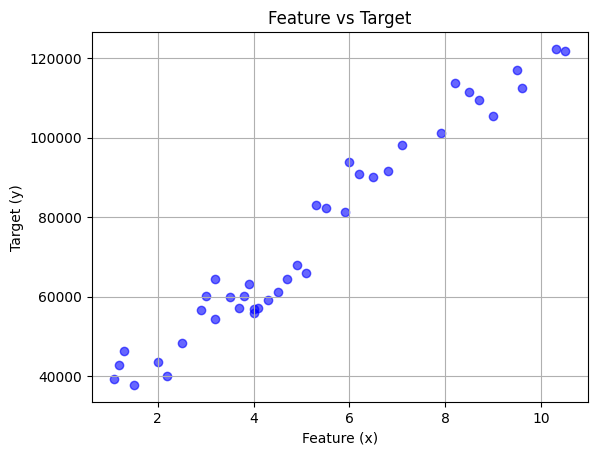

In [27]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)  # correct way to check version

# Now test the plot
plt.scatter(x, y, color='blue', alpha=0.6)
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.title("Feature vs Target")
plt.grid(True)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship between the feature and the target is increasing.


### Step 7. Initialize a regression model

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (32, 1)
x_test shape: (8, 1)
y_train shape: (32, 1)
y_test shape: (8, 1)


### Step 9.a Train the model on the training set

In [30]:
model.fit(x_train, y_train)  # train the model  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [31]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [[9408.03127251]]
Intercept: [26716.25017615]


### Step 9.c how much salary does a person get with 2 years of experience?

In [32]:
pred = model.predict([[2]])
print("Salary with 2 years experience:", pred[0][0])

Salary with 2 years experience: 45532.3127211587


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [33]:
increase = model.coef_[0][0] * 0.5
print("Salary increase per 6 months:", increase)

Salary increase per 6 months: 4704.01563625329


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [34]:
print("Estimated salary with 0 experience:", model.intercept_[0])

Estimated salary with 0 experience: 26716.250176145535


### Step 10. Evaluate the model on the test set

In [35]:
y_pred = model.predict(x_test)

print("R² Score:", model.score(x_test, y_test))

from sklearn.metrics import mean_squared_error
import numpy as np
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", np.sqrt(mse))

R² Score: 0.9068577573647874
MSE: 48077731.16919359
RMSE: 6933.810724932834


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [36]:
samples = x_test[:3]
true_labels = y_test[:3]
predictions = model.predict(samples)

for i in range(3):
    print(f"Sample {i+1}: Predicted={predictions[i][0]:.2f}, Actual={true_labels[i][0]:.2f}")

Sample 1: Predicted=69052.39, Actual=61111.00
Sample 2: Predicted=64348.38, Actual=56957.00
Sample 3: Predicted=64348.38, Actual=55794.00


### Step 12. Plot the data and the regression line

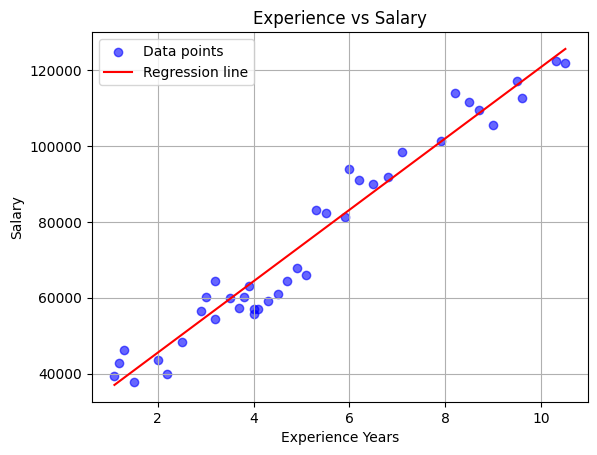

In [37]:
plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')
plt.plot(x, model.predict(x), color='red', label='Regression line')
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.legend()
plt.grid(True)
plt.show()